In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('/content/books.csv', on_bad_lines='skip')

In [14]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bookID,11123.0,2.131086e+04,1.309473e+04,1.000000e+00,1.027750e+04,2.028700e+04,3.210450e+04,4.564100e+04
average_rating,11123.0,3.934075e+00,3.504853e-01,0.000000e+00,3.770000e+00,3.960000e+00,4.140000e+00,5.000000e+00
isbn13,11123.0,9.759880e+12,4.429758e+11,8.987060e+09,9.780345e+12,9.780582e+12,9.780872e+12,9.790008e+12
num_pages,11123.0,3.364056e+02,2.411526e+02,0.000000e+00,1.920000e+02,2.990000e+02,4.160000e+02,6.576000e+03
ratings_count,11123.0,1.794285e+04,1.124992e+05,0.000000e+00,1.040000e+02,7.450000e+02,5.000500e+03,4.597666e+06
text_reviews_count,11123.0,5.420481e+02,2.576620e+03,0.000000e+00,9.000000e+00,4.700000e+01,2.380000e+02,9.426500e+04


In [19]:
df.shape

(11123, 12)

In [18]:
df.columns = df.columns.str.strip()

In [20]:
df['num_pages'] = pd.to_numeric(df['num_pages'], errors='coerce')

In [21]:
df['ratings_count'] = pd.to_numeric(df['ratings_count'], errors='coerce')

In [22]:
df['text_reviews_count'] = pd.to_numeric(df['text_reviews_count'], errors='coerce')

In [23]:
df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce')

In [25]:
df['publication_date'] = pd.to_datetime(df['publication_date'], errors='coerce')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   bookID              11123 non-null  int64         
 1   title               11123 non-null  object        
 2   authors             11123 non-null  object        
 3   average_rating      11123 non-null  float64       
 4   isbn                11123 non-null  object        
 5   isbn13              11123 non-null  int64         
 6   language_code       11123 non-null  object        
 7   num_pages           11123 non-null  int64         
 8   ratings_count       11123 non-null  int64         
 9   text_reviews_count  11123 non-null  int64         
 10  publication_date    11121 non-null  datetime64[ns]
 11  publisher           11123 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 1.0+ MB


In [30]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.isna().sum()

,0
bookID,0
title,0
authors,0
average_rating,0
isbn,0
isbn13,0
language_code,0
num_pages,0
ratings_count,0
text_reviews_count,0


In [36]:
df = df.dropna(subset='publication_date')

In [37]:
df.isnull().sum().sum()

np.int64(0)

In [39]:
df['average_rating'].describe().T

,average_rating
count,11121.000000
mean,3.934058
std,0.350513
min,0.000000
25%,3.770000
50%,3.960000
75%,4.140000
max,5.000000


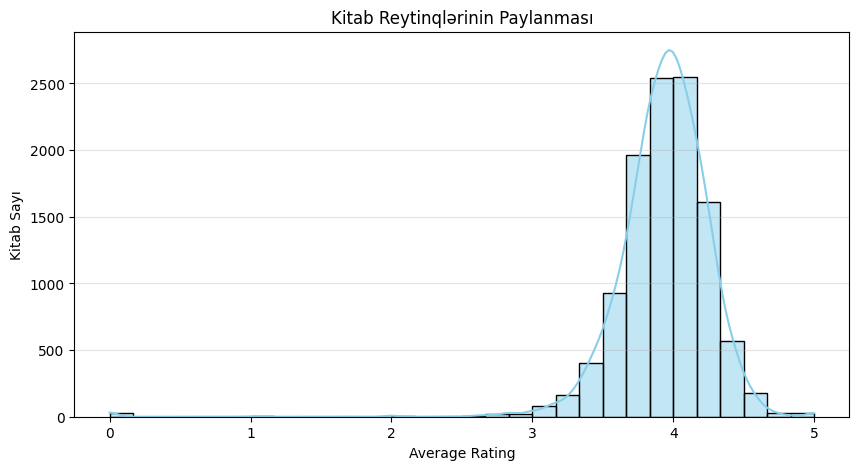

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['average_rating'], bins=30, kde=True, color='skyblue')
plt.title('Kitab Reytinqlərinin Paylanması')
plt.xlabel('Average Rating')
plt.ylabel('Kitab Sayı')
plt.grid(axis='y', alpha=0.35)

plt.show()

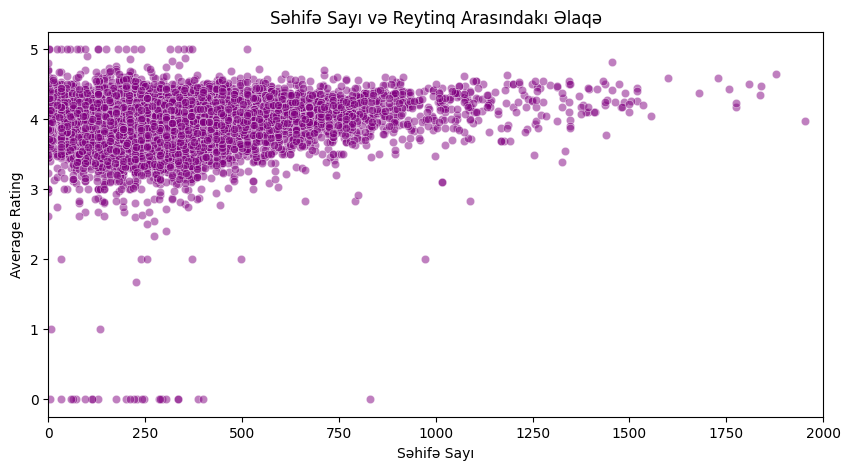

In [41]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['num_pages'], y=df['average_rating'], alpha=0.5, color='purple')
plt.title('Səhifə Sayı və Reytinq Arasındakı Əlaqə')
plt.xlabel('Səhifə Sayı')
plt.ylabel('Average Rating')
plt.xlim(0, 2000)

plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [44]:
current_year = 2026

df['book_age_years'] = current_year - df['publication_date'].dt.year

In [45]:
X = df[['title', 'authors', 'language_code', 'publisher', 'num_pages', 'ratings_count', 'text_reviews_count', 'book_age_years']]

In [47]:
y = df['average_rating']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [49]:
numerical_cols = ['num_pages', 'ratings_count', 'text_reviews_count', 'book_age_years']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [51]:
categorical_cols = ['language_code', 'publisher']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [52]:
text_title_transformer = TfidfVectorizer(max_features=500, stop_words='english')

text_authors_transformer = TfidfVectorizer(max_features=500, stop_words='english')

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('txt_title', text_title_transformer, 'title'),
        ('txt_authors', text_authors_transformer, 'authors')
    ]
)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [56]:
X_train.shape

(8896, 8)

In [59]:
X_train_processed.shape

(8896, 3049)

In [60]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [62]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])

In [63]:
ridge_pipeline.fit(X_train, y_train)

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_pages', 'ratings_count',
                                                   'text_reviews_count',
                                                   'book_age_years']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['language_code',
                                                   'publisher']),
                                                 ('txt_title',
                                                  TfidfVectorizer(max_features=500,
                                                                  stop_words='english'),
                                                  'title'),
                                                 ('txt_authors',
                                                  TfidfVectorizer(max_features=500,
                                                                  stop_words='english'),
                                                  'authors')])),
                ('regressor',
                 RandomForestRegressor(n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [68]:
def evaluate_model(model_pipeline, X_test, y_test, model_name):
  preds = model_pipeline.predict(X_test)
  r2 = r2_score(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  mae = mean_absolute_error(y_test, preds)
  print(f"{model_name}")
  print()
  print('R2 Score:', r2)
  print('RMSE:', rmse)
  print('MAE:', mae)
  return preds

In [69]:
ridge_preds = evaluate_model(ridge_pipeline, X_test, y_test, "Ridge Regression (Baseline)")

Ridge Regression (Baseline)

R2 Score: 0.06514300918001414
RMSE: 0.33954548974763465
MAE: 0.2122711674451974


In [70]:
rf_preds = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest (Baseline)")

Random Forest (Baseline)

R2 Score: 0.2429677937353275
RMSE: 0.30555018711031917
MAE: 0.202100804494382


In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [74]:
param_distributions = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5, 10]
}

tuned_rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

tuned_rf_search.fit(X_train, y_train)

best_rf_pipeline = tuned_rf_search.best_estimator_
tuned_rf_preds = evaluate_model(best_rf_pipeline, X_test, y_test, "Tuned Random Forest")

Tuned Random Forest

R2 Score: 0.241355284453315
RMSE: 0.30587543114798194
MAE: 0.20158680269243864


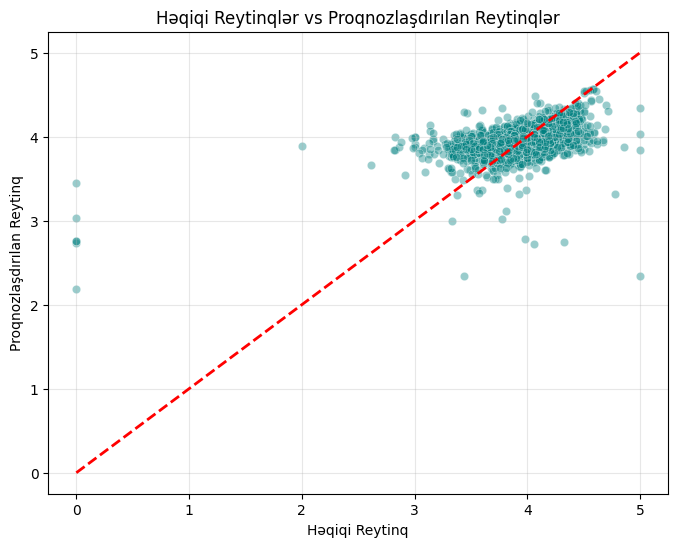

In [75]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=tuned_rf_preds, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Həqiqi Reytinqlər vs Proqnozlaşdırılan Reytinqlər')
plt.xlabel('Həqiqi Reytinq')
plt.ylabel('Proqnozlaşdırılan Reytinq')
plt.grid(True, alpha=0.3)

plt.show()